# Import and Dataset Loading

In [1]:
import numpy as np
import pandas as pd 
import os
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
health_dir = '/kaggle/input/datasets/pratikyuvrajchougule/health-and-lifestyle-data-for-regression/'
csv_file = 'synthetic_health_data.csv'
df = pd.read_csv(os.path.join(health_dir, csv_file))

print(df.shape)
df.head()

(1000, 8)


,Age,BMI,Exercise_Frequency,Diet_Quality,Sleep_Hours,Smoking_Status,Alcohol_Consumption,Health_Score
0,45.960570,31.996777,5,55.403270,7.300359,0,2.834707,70.542122
1,38.340828,29.623168,6,41.838357,7.012419,1,7.199517,57.244637
2,47.772262,25.298152,5,76.904948,6.028641,1,4.097944,96.333722
3,58.276358,21.765316,2,49.756767,5.802714,1,3.649377,61.321783
4,37.190160,28.491117,2,44.218737,7.912548,0,2.839795,67.175894


> This setup code blocks equips the environment with our main dependencies. It loads pandas and numpy for working with data, matplotlib and seaborn for drawing, and sklearn modules for data transformation, the three different regression model types (Linear, Lasso and ElasticNet), and metrics for measurement of model performance. Lastly, it builds the local Kaggle folder path, reads the CSV file into a DataFrame, and displays the dataset's dimensions and first few rows for familiarizing with its structure as shown clearly below: 


## Dataset Preprocessing

> Here, it shows the dataset consists of 1,000 records mapping seven specific lifestyle and biological features such as BMI, diet quality, and sleep hours, to calculate an overall continuous Health_Score.


### Checking Dataset Datatypes

In [3]:
df.dtypes

Age                    float64
BMI                    float64
Exercise_Frequency       int64
Diet_Quality           float64
Sleep_Hours            float64
Smoking_Status           int64
Alcohol_Consumption    float64
Health_Score           float64
dtype: object

> Printing with the .isna() and .sum() function, the dataset shows that it consists entirely of numerical data types (float64 and int64), meaning no categorical text encoding is necessary.Here, it shows the dataset consists of 1,000 records mapping seven specific lifestyle and biological features such as BMI, diet quality, and sleep hours, to calculate an overall continuous Health_Score.


### Finding Nulls in Dataset

In [4]:
print(df.isna().sum())

Age                    0
BMI                    0
Exercise_Frequency     0
Diet_Quality           0
Sleep_Hours            0
Smoking_Status         0
Alcohol_Consumption    0
Health_Score           0
dtype: int64


There are zero null or missing values across all columns, confirming the dataset is completely populated. Because the dataset is inherently complete and already structured in a machine-readable numeric format, we can entirely bypass standard data cleaning procedures, like missing value imputation or one-hot encoding and move straight into feature scaling and model training.

# Exploratory Data Analysis (Correlation)

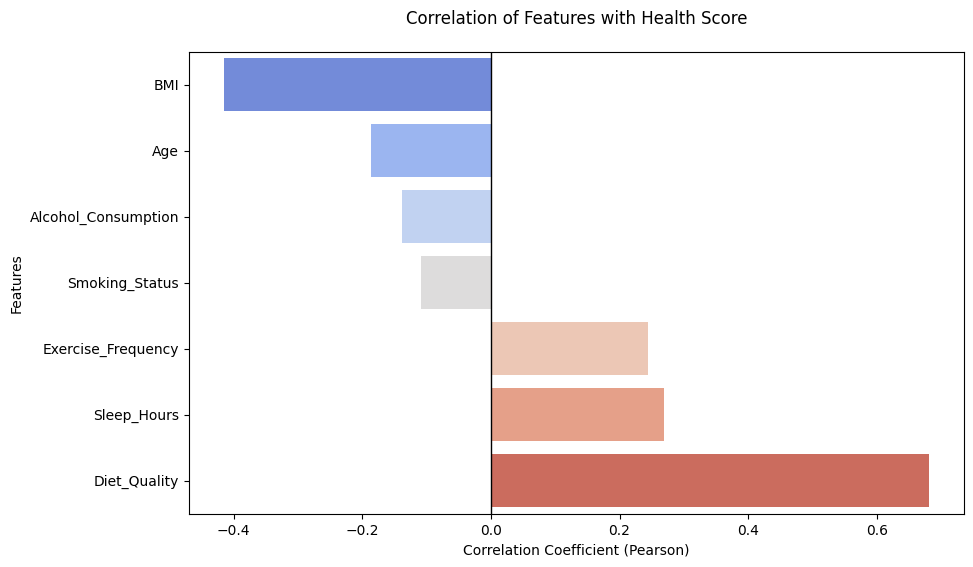

In [5]:
plt.figure(figsize=(10, 6))
target_corr = df.corr()['Health_Score'].drop('Health_Score').sort_values()
sns.barplot(
    x=target_corr.values, 
    y=target_corr.index, 
    palette='coolwarm',
    hue=target_corr.index,
    legend=False
)

plt.title("Correlation of Features with Health Score", pad=20)
plt.xlabel("Correlation Coefficient (Pearson)")
plt.ylabel("Features")
plt.axvline(x=0, color='black', linewidth=1)
plt.show()

## Observation
This chart serves as a really straightforward visual reference to indicate which lifestyle habits are contributing to a person's health score and which ones are detracting from it. Everything that extends to the right of the central zero line depicts a positive influence, and in other words, as you engage more in these activities, your health score increases. 
- The large red bar at the bottom plainly spells out diet quality as the leading factor for health augmentation according to this dataset. Although getting proper sleep and working out regularly are good for your health score, their combined effect is less than half that of merely eating a wholesome diet.
- On the other hand, the blue bars extending to the left indicate those elements that physically lower ones health score. Body Mass Index (BMI) is the largest negative factor here, showing that with rising BMI, a person's overall health score will dramatically fall.
- The point is, despite the fact that aging, drinking alcohol, and smoking do bring risks to health, they are not nearly as harmful in this particular dataset when their effect sizes are compared to that of a high BMI, which is the heaviest penalty. 


# Model Implementation

### Setting Target (y) and Features (X)

In [6]:
target = "Health_Score"
X = df.drop(columns=[target])
y = df[target]

print("Samples: ", X.shape[0], "Features: ", X.shape[1])

Samples:  1000 Features:  7


> This snippet isolates our independent variables (X) from the dependent target variable (y, Health_Score). The console output validates our resulting matrix, confirming a clean split of 1,000 samples across the 7 distinct lifestyle predictors.

### Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)
print("Training Samples: ", X_train.shape[0], "Test Samples: ", X_test.shape[0])

Training Samples:  700 Test Samples:  300


> Here, we partition the dataset to properly evaluate our model's ability to generalize to unseen data. We allocate 70% of the records (700 samples) to train the algorithm and reserve the remaining 30% (300 samples) strictly for testing. A fixed random_state is applied to guarantee that these specific splits are perfectly reproducible across different execution runs.


### Dataset Feature Scaling

In [8]:
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

> This operation normalizes our numerical features such that their mean becomes zero and their variance equals one. If our models are going to base their decisions on distances or if we are going to use the models which apply regularization techniques (for instance, Lasso and Elastic Net), we have to do this step. Otherwise, these models will disproportionately penalize the weights of features according to their original units. To guarantee no data leakage, the StandardScaler is only trained on the training dataset and then it is used to transform the training and testing matrices. 


### Model Implementation

In [9]:
models = {
    "LinearRegression": LinearRegression(), 
    "Lasso": Lasso(alpha=1.0, max_iter=1000), 
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

> This block defines a dictionary containing the three distinct regression algorithms we will evaluate. It instantiates a standard LinearRegression algorithm alongside two regularized models: Lasso (which applies an L1 penalty for feature selection) and ElasticNet (which combines both L1 and L2 penalties). Hyperparameters such as alpha (controlling regularization strength) and max_iter (increasing the solver limit for convergence) are explicitly declared to ensure stable and reproducible training.

### Training and Evaluation
This block below acts as the core experimental loop for the comparative analysis. It iterates through the initialized dictionary, sequentially fitting each model using the standardized training data. Once trained, the model generates predictions for both the training and testing sets.

In [10]:
feature_names = X_train.columns

results = []

for name, model in models.items():        
    model.fit(X_train_scaled, y_train)
            
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
            
    r2_train = r2_score(y_train, y_train_pred)
    rmse_train = mean_squared_error(y_train, y_train_pred) ** 0.5
        
    r2_test = r2_score(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_test = mean_squared_error(y_test, y_test_pred) ** 0.5
            
    model_results = {
        "Model": name,
        "Train R2": r2_train,
        "Test R2": r2_test,
        "R2 Gap": r2_train - r2_test, 
        "Train RMSE": rmse_train,
        "Test RMSE": rmse_test,
        "Test MAE": mae_test, 
    }
    
    coef_dict = {f"Coef_{feat}": coef for feat, coef in zip(feature_names, model.coef_)}
    model_results.update(coef_dict)
    
    results.append(model_results)

results_df = pd.DataFrame(results)
display(results_df)

,Model,Train R2,Test R2,R2 Gap,Train RMSE,Test RMSE,Test MAE,Coef_Age,Coef_BMI,Coef_Exercise_Frequency,Coef_Diet_Quality,Coef_Sleep_Hours,Coef_Smoking_Status,Coef_Alcohol_Consumption
0,LinearRegression,0.841578,0.814024,0.027554,5.307561,6.158254,4.732168,-2.553547,-5.668042,3.585711,8.907080,3.817507,-1.944434,-2.246952
1,Lasso,0.800231,0.792238,0.007993,5.960066,6.508962,5.117583,-1.396932,-4.558818,2.646301,7.877720,2.794164,-0.951589,-1.145560
2,ElasticNet,0.703414,0.699223,0.004191,7.262107,7.831615,6.126663,-1.206072,-3.363617,2.092204,5.572244,2.166940,-0.991995,-1.057114


Starting with the raw error metrics, the standard Linear Regression model delivered the most accurate predictions. It achieved the lowest Test Mean Absolute Error (MAE) of 4.73, meaning its predictions for the continuous Health Score deviate by an average of only 4.7 points. It also recorded the lowest Test Root Mean Squared Error (RMSE) at 6.16. As we introduce regularization, the error visibly increases. The Lasso model saw its Test MAE rise to 5.12, and ElasticNet performed the poorest with an MAE of 6.13 and an RMSE of 7.83. This initial look at the error metrics suggests that penalizing the feature weights actively degrades the model's raw predictive power for this specific dataset.

The Test R2 scores confirm the hierarchy established by the error metrics. The standard Linear Regression model successfully explains the highest amount of variance in the unseen data, achieving a Test R2 of approximately 0.814 (81.4%). The Lasso model drops slightly to 0.792, while the heavier penalties of the ElasticNet model push the Test R2 down significantly to 0.699. Because the standard model outperforms the regularized versions, we can conclude that all the provided lifestyle features carry valuable, legitimate predictive weight. Applying L1 and L2 penalties forces the model to discard useful information, which actively hurts its overall accuracy.

Finally, analyzing the R2 Gap provides a clear picture of model generalization and helps us check for overfitting or underfitting. The standard Linear Regression model shows an R2 Gap of just 0.027 between its training and testing performance. This is an incredibly healthy margin, indicating the model fits the data very well without memorizing the noise (overfitting). As expected by their design, the regularized models restrict the learning process and close this gap even further, with Lasso shrinking the gap to 0.008 and ElasticNet down to 0.004. However, because the standard Linear Regression model's baseline gap is already so small, the extreme regularization of Lasso and ElasticNet is unnecessary. The standard model remains the optimal choice, offering the highest accuracy while maintaining excellent generalization.

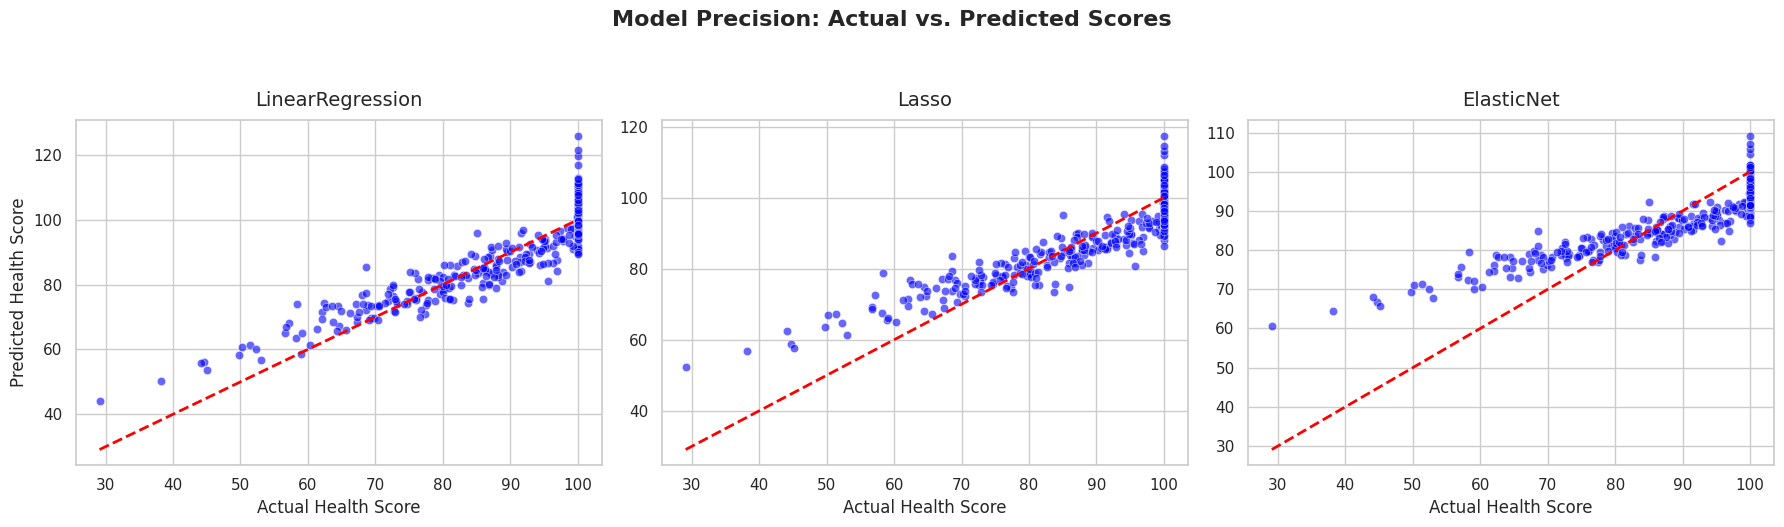

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = list(models.keys())
sns.set_theme(style="whitegrid")

# ==========================================
# FIGURE 1: Actual vs. Predicted
# ==========================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(model_names):
    model = models[name]
    y_test_pred = model.predict(X_test_scaled)
    
    sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6, color='blue', ax=axes1[i])
    # Draw the red "perfect prediction" reference line
    axes1[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
    
    axes1[i].set_title(f'{name}', fontsize=14, pad=10)
    axes1[i].set_xlabel('Actual Health Score', fontsize=12)
    if i == 0: # Only add the y-label to the leftmost plot to keep it clean
        axes1[i].set_ylabel('Predicted Health Score', fontsize=12)

fig1.suptitle('Model Precision: Actual vs. Predicted Scores', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

> The graphs illustrate the accuracy of each algorithm in estimating an individual's actual health score by plotting their predictions against a red diagonal line. This red line stands for absolute perfection, meaning a model's prediction exactly matches the actual outcome. If we turn to the chart on the far left, the standard linear regression model appears to be the most accurate. The blue points on this graph are very close together and nearly trace the red line all the way from bottom to top, which shows that this model's outputs are dependable and it hardly ever makes predictions that deviate a lot from the real patient results.

> When we look further right at the penalized algorithms, the predictive precision is markedly reduced, as you can see. In the Lasso diagram, the points slightly move away from the center, and when we finally get to the Elastic Net model, the previously compact group of points has become a very loose cloud. This visual dispersal is a great representation of our earlier mathematical conclusions; by requiring the models to impose harsh penalties and diminish the significance of the mapped lifestyle habits, we are, in fact, reducing their effectiveness in accurately determining a person's true health score. 

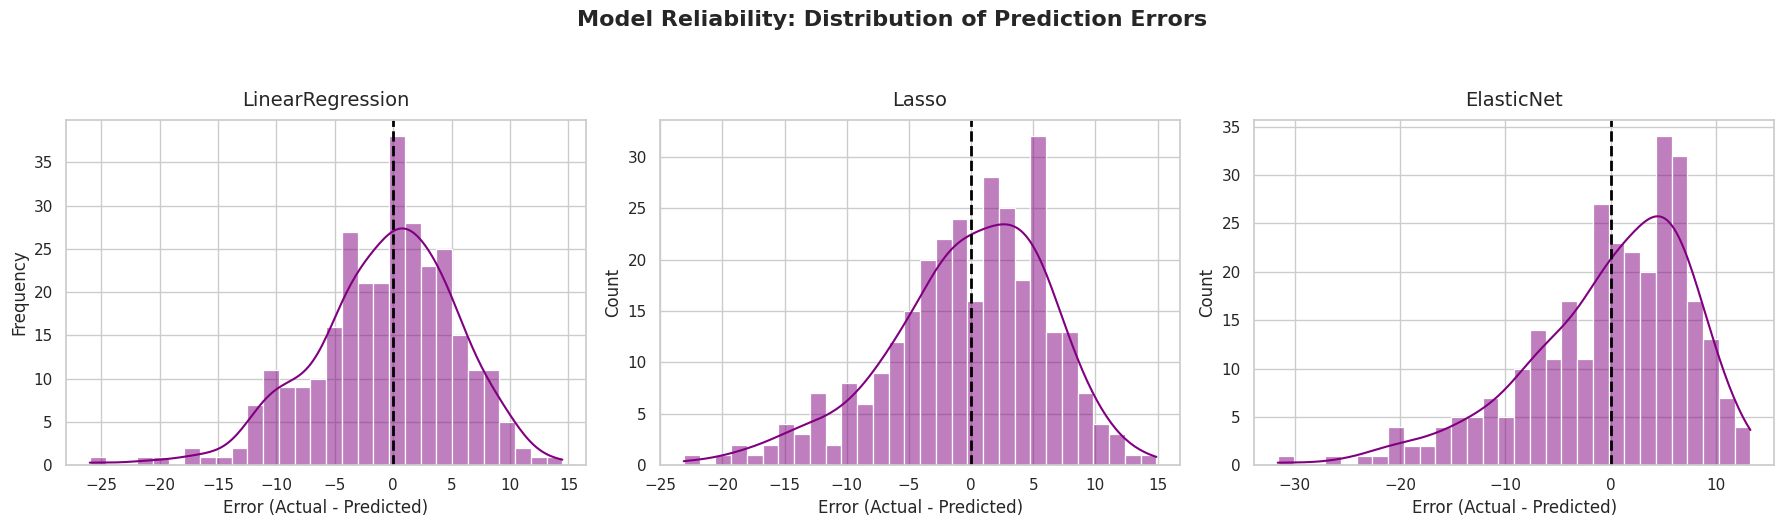

In [12]:
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))

for i, name in enumerate(model_names):
    model = models[name]
    y_test_pred = model.predict(X_test_scaled)
    residuals = y_test - y_test_pred
    
    sns.histplot(residuals, kde=True, bins=30, color='purple', ax=axes2[i])
    axes2[i].axvline(x=0, color='black', linestyle='--', linewidth=2)
    
    axes2[i].set_title(f'{name}', fontsize=14, pad=10)
    axes2[i].set_xlabel('Error (Actual - Predicted)', fontsize=12)
    if i == 0:
        axes2[i].set_ylabel('Frequency', fontsize=12)

fig2.suptitle('Model Reliability: Distribution of Prediction Errors', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

> The second set of charts measures the reliability of our algorithms by looking at the exact size of the mistakes they make. When we subtract the predicted health score from the actual health score, a perfect guess lands exactly on the zero-error line in the middle. Looking at the standard Linear Regression chart on the far left, we see a tall, narrow bell shape perfectly centered over this zero mark. This indicates that when the basic model does make a mistake, it is usually off by a very small amount, and it does not have a bad habit of consistently guessing too high or too low.

> As we introduce mathematical penalties to simplify the decision-making process, we can physically see this reliability fade. In the middle chart representing the Lasso algorithm, the tall peak drops significantly, meaning the model makes highly accurate guesses far less often. By the time we evaluate the ElasticNet model on the far right, the purple bell curve has completely flattened and stretched outward. This visual widening confirms that forcing these strict rules onto our specific lifestyle features causes the model to become increasingly erratic, resulting in much larger and more frequent prediction errors.

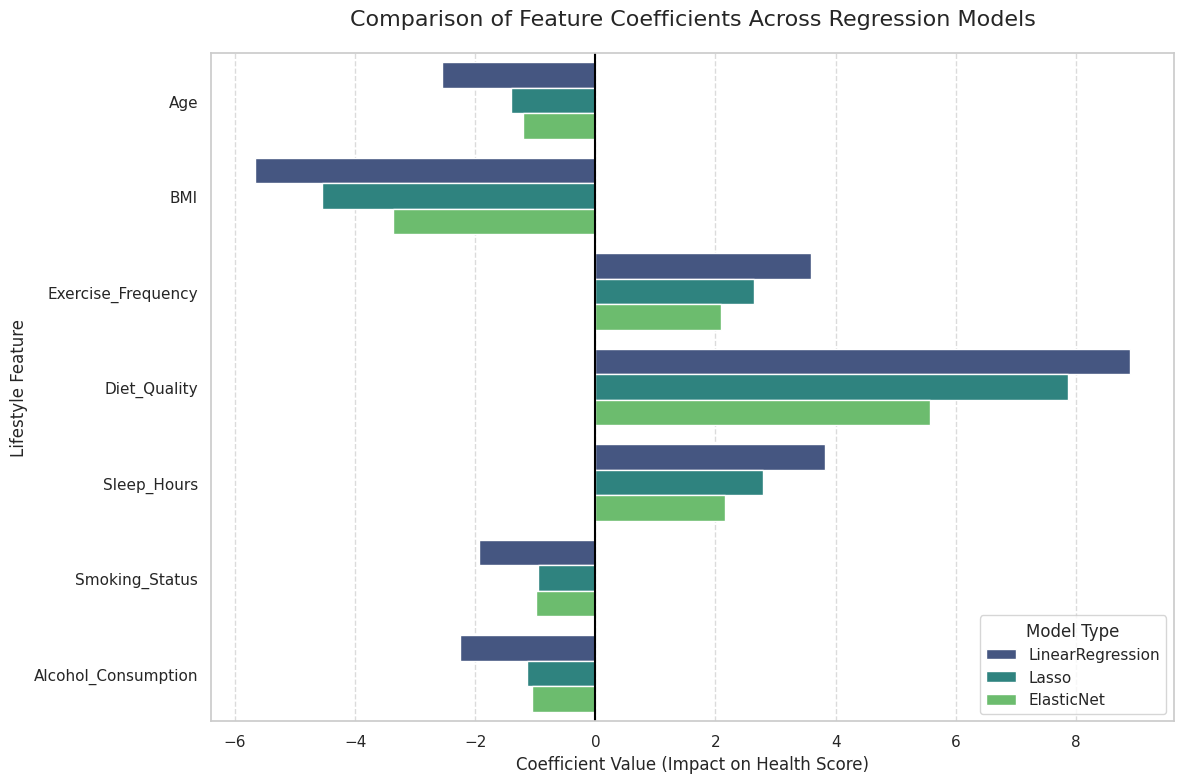

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

melted_df = results_df.melt(
    id_vars=['Model'], 
    value_vars=['Coef_Age', 'Coef_BMI', 'Coef_Exercise_Frequency', 
                'Coef_Diet_Quality', 'Coef_Sleep_Hours', 
                'Coef_Smoking_Status', 'Coef_Alcohol_Consumption'],
    var_name='Feature', 
    value_name='Coefficient'
)

melted_df['Feature'] = melted_df['Feature'].str.replace('Coef_', '')

plt.figure(figsize=(12, 8))
sns.barplot(
    data=melted_df, 
    x='Coefficient', 
    y='Feature', 
    hue='Model', 
    palette='viridis' 
)

plt.title('Comparison of Feature Coefficients Across Regression Models', fontsize=16, pad=20)
plt.xlabel('Coefficient Value (Impact on Health Score)', fontsize=12)
plt.ylabel('Lifestyle Feature', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5) 
plt.legend(title='Model Type', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

> When we see how the models gave importance to our positive lifestyle habits, they totally reflect the visual patterns we noticed in the previous correlation chart. The huge red bar that indicated diet quality in our chart was turned into the strongest driving force by all three models. Linear standard regression even gave it a superior weight of 8. 90. In other words, the models found that eating healthily was the most effective single action to raise a health score even when they accounted for all other factors simultaneously. The same way the moderate positive trends we observed for sleeping and exercise in the chart were confirmed by the models, which gave them weights of 3. 81 and 3. 58 correspondingly. These weights show that these behaviors will still give a decent, but comparatively smaller, increase to overall health. 

> On the negative side, the models confirmed that Body Mass Index acts as the heaviest anchor on a person's health score, directly aligning with the large blue bar from our initial chart by assigning it a severe penalty of -5.66. Minor negative factors like age, alcohol consumption, and smoking also matched their chart positions, pulling the score down by roughly one to two points each in the standard model. Interestingly, as we applied stricter rules using the Lasso and Elastic Net models, we can see every single one of these values shrink closer to zero—for example, the penalty for BMI decreases from -5.66 down to -3.36 in the final model. However, because the ranking of these habits never changed during this shrinking process, we can confidently trust that the core relationship between these specific lifestyle choices and a person's health is incredibly stable.

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0], 
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99] 
}

elastic_base = ElasticNet(max_iter=20000)

grid_search = GridSearchCV(
    estimator=elastic_base,
    param_grid=param_grid,
    scoring='r2',      
    cv=5,               
    verbose=1      
)

print("Executing Grid Search (this will train 35 different models 5 times each)...")
grid_search.fit(X_train_scaled, y_train)

Executing Grid Search (this will train 35 different models 5 times each)...
Fitting 5 folds for each of 35 candidates, totalling 175 fits


GridSearchCV(cv=5, estimator=ElasticNet(max_iter=20000),
             param_grid={'alpha': [0.1, 1.0, 10.0, 100.0, 1000.0],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]},
             scoring='r2', verbose=1)

In [15]:
print("\n--- Grid Search Results ---")
print(f"Optimal Parameters: {grid_search.best_params_}")

best_elastic_model = grid_search.best_estimator_
y_pred_best = best_elastic_model.predict(X_test_scaled)

best_r2 = r2_score(y_test, y_pred_best)
best_rmse = mean_squared_error(y_test, y_pred_best) ** 0.5
best_mae = mean_absolute_error(y_test, y_pred_best)

print("\n--- Test Set Performance (Optimized Model) ---")
print(f"R2 Score: {best_r2:.6f}")
print(f"RMSE:     {best_rmse:.2f}")
print(f"MAE:      {best_mae:.2f}")

print("\nOptimized Coefficients:")
for feature, coef in zip(X.columns, best_elastic_model.coef_):
    print(f"{feature:>35}: {coef:>10.2f}")


--- Grid Search Results ---
Optimal Parameters: {'alpha': 0.1, 'l1_ratio': 0.99}

--- Test Set Performance (Optimized Model) ---
R2 Score: 0.815393
RMSE:     6.14
MAE:      4.73

Optimized Coefficients:
                                Age:      -2.44
                                BMI:      -5.55
                 Exercise_Frequency:       3.49
                       Diet_Quality:       8.80
                        Sleep_Hours:       3.71
                     Smoking_Status:      -1.84
                Alcohol_Consumption:      -2.14


In [16]:
results_df.to_csv('regression_comparison_results.csv', index=False)
print("File saved to output!")

File saved to output!
